In [ ]:
import os

if os.getcwd().endswith("scripts"):
    os.chdir("..")
os.getcwd()

'/mnt/mergerfs/yuzihan/MergedWorkSpace/44-AI4Astronomy/AI4Astronomy'

# Nature 2021 energy distribution: AI formula vs paper formula

This notebook compares the SR Agent energy-distribution formula with the Nature 2021 Eq. (1) family. The histogram follows `scripts/run_blinkverse_sr_agent.py`: FAST bursts from `FRB20121102A`, positive `energy`, 40 logarithmic energy bins, and the Figure 2 bottom-panel target `burst_rate_h_per_energy_bin = counts / 59.5 h`.


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from argparse import Namespace
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scripts.run_blinkverse_sr_agent import build_task

exp_path = Path('logs/260624_nature2021_figure2_energy/figure2_energy_rate')
args = Namespace(**json.load(open(exp_path / 'args.json')))
print(
    f"task={args.task!r}, "
    f"bins={args.bins!r}, "
    f"data_dir={args.data_dir!r}"
)

X, y, problem = build_task(args)
data = X | y
data


task='nature2021_energy_distribution', bins=40, data_dir='data/blinkverse'


{'energy_erg': array([1.91670685e+36, 3.57634282e+36, 4.40284732e+36, 5.42035971e+36,
        6.67302253e+36, 8.21517983e+36, 1.01137347e+37, 1.24510518e+37,
        1.53285305e+37, 1.88710040e+37, 2.32321546e+37, 2.86011814e+37,
        3.52110077e+37, 4.33483866e+37, 5.33663402e+37, 6.56994757e+37,
        8.08828390e+37, 9.95751271e+37, 1.22587264e+38, 1.50917581e+38,
        1.85795127e+38, 2.28732987e+38, 2.81593927e+38, 3.46671203e+38,
        4.26788049e+38, 5.25420160e+38, 6.46846475e+38, 7.96334807e+38,
        9.80370380e+38, 1.20693718e+39, 1.48586430e+39, 1.82925239e+39,
        2.25199858e+39, 2.77244281e+39, 3.41316339e+39, 4.20195660e+39,
        5.17304248e+39, 6.36854949e+39]),
 'burst_rate_h_per_energy_bin': array([0.01680672, 0.01680672, 0.05042017, 0.06722689, 0.05042017,
        0.08403361, 0.08403361, 0.1512605 , 0.21848739, 0.40336134,
        0.94117647, 1.32773109, 1.79831933, 2.99159664, 3.2605042 ,
        3.02521008, 2.50420168, 1.36134454, 1.22689076, 0.823

In [27]:
# AI-discovered formulas from the Figure 2 energy-rate setup.
print(json.load(open(exp_path / 'result.json'))['best_formula'])

def f_ai(x):
    x = np.asarray(x, dtype=float)
    return (
        3.182297320663295
        * np.exp(-((np.log(x) / np.log(9.99998036716754) - 37.735789714984854) ** 2) / 0.09070762012831875)
        + 0.9804819518573495
        * np.exp(-((np.log(x) / np.log(10.00002098540179) - 38.53841217583469) ** 2) / 0.16663120864638276)
    )

# exp_path2 = Path('logs/260624_nature2021_figure2_energy/figure2_energy_rate_loghint')
# print(json.load(open(exp_path2 / 'result.json'))['best_formula'])

# def f_ai2(x):
#     x = np.asarray(x, dtype=float)
#     return (
#         2.6189725782217015
#         * np.exp(-0.6932688179960219 * ((np.log(x) / np.log(10.000099063115792) - 37.72329945960833) / 0.2029994718698678) ** 2)
#         + 0.9301113511499416
#         * np.exp(-0.5348797961202448 * ((np.log(x) / np.log(9.936162507137757) - 38.308322871933896) / 0.6214364503720315) ** 2)
#     )

exp_path3 = Path('logs/260624_nature2021_cosh_hunt/figure2_energy_sech_hint_1')
print(json.load(open(exp_path3 / 'result.json'))['best_formula'])

def f_ai3(x):
    x = np.asarray(x, dtype=float)
    return (
        3.300602060576377
        * (1 / np.cosh((np.log(x) / np.log(10.013501527672446) - 37.71824410263978) / 0.17555861489667174))
        + 0.9456314694478786
        * (1 / np.cosh((np.log(x) / np.log(9.995449374687064) - 38.58006322275906) / 0.22430576586018822))
    )


3.182297320663295 * exp(-(log(energy_erg) / log(9.99998036716754) - 37.735789714984854) ** 2 / 0.09070762012831875) + 0.9804819518573495 * exp(-(log(energy_erg) / log(10.00002098540179) - 38.53841217583469) ** 2 / 0.16663120864638276)
3.300602060576377 * sech((log(energy_erg) / log(10.013501527672446) - 37.71824410263978) / 0.17555861489667174) + 0.9456314694478786 * sech((log(energy_erg) / log(9.995449374687064) - 38.58006322275906) / 0.22430576586018822)


In [29]:
x = np.asarray(data['energy_erg'], dtype=float)
y_true = np.asarray(data['burst_rate_h_per_energy_bin'], dtype=float)
log_bin_width = np.median(np.diff(np.log10(np.sort(x))))
width_factor = 10 ** (0.5 * log_bin_width) - 10 ** (-0.5 * log_bin_width)
E_ln = 4.8e37
sigma_ln_natural = 0.52
sigma_ln_log10 = sigma_ln_natural / np.log(10.0)
E_switch = 1.0e38
E_cauchy = 8.16e38
alpha_E = 1.85

def _nature_shapes_point(E):
    E = np.asarray(E, dtype=float)

    ln_shape = np.exp(
        -0.5 * ((np.log10(E) - np.log10(E_ln)) / sigma_ln_log10) ** 2
    )

    epsilon_E = (E >= E_switch).astype(float)
    cauchy_shape = epsilon_E / (1.0 + (E / E_cauchy) ** alpha_E)

    return ln_shape, cauchy_shape

def nature_components(E, average_over_log_bin=True, n_grid=129):
    E = np.asarray(E, dtype=float)

    if not average_over_log_bin:
        return _nature_shapes_point(E)

    log_center = np.log10(E)
    offsets = np.linspace(-0.5 * log_bin_width, 0.5 * log_bin_width, n_grid)
    E_grid = 10 ** (log_center[..., None] + offsets)

    ln_grid, cauchy_grid = _nature_shapes_point(E_grid)
    return ln_grid.mean(axis=-1), cauchy_grid.mean(axis=-1)

ln_shape, cauchy_shape = nature_components(x, average_over_log_bin=True)

A_ln, A_cauchy = np.linalg.lstsq(np.vstack([ln_shape, cauchy_shape]).T, y_true, rcond=None)[0]

def f_nature(E):
    ln_shape, cauchy_shape = nature_components(E, average_over_log_bin=True)
    return A_ln * ln_shape + A_cauchy * cauchy_shape

def f_nature_ln(E):
    ln_shape, _ = nature_components(E, average_over_log_bin=True)
    return A_ln * ln_shape

def f_nature_cauchy(E):
    _, cauchy_shape = nature_components(E, average_over_log_bin=True)
    return A_cauchy * cauchy_shape


In [33]:
x = data['energy_erg']
y_true = data['burst_rate_h_per_energy_bin']
df_list = []

for name, fn in [
    ('AI: two-log-Gaussian', f_ai),
    # ('AI: two-log-Gaussian loghint', f_ai2),
    ('AI: double-sech', f_ai3),
    ('Nature 2021 Eq.(1)', f_nature),
]:
    y_pred = fn(x)
    df_list.append({
        'model': name,
        'R2': r2_score(y_true, y_pred),
        'RMSE': mean_squared_error(y_true, y_pred) ** 0.5,
        'MAE': mean_absolute_error(y_true, y_pred),
    })

df_metrics = pd.DataFrame(df_list).set_index('model').sort_values('R2')
df_metrics


,R2,RMSE,MAE
model,,,
Nature 2021 Eq.(1),0.926202,0.242993,0.159346
AI: two-log-Gaussian,0.984203,0.112423,0.084406
AI: double-sech,0.990254,0.088304,0.067719


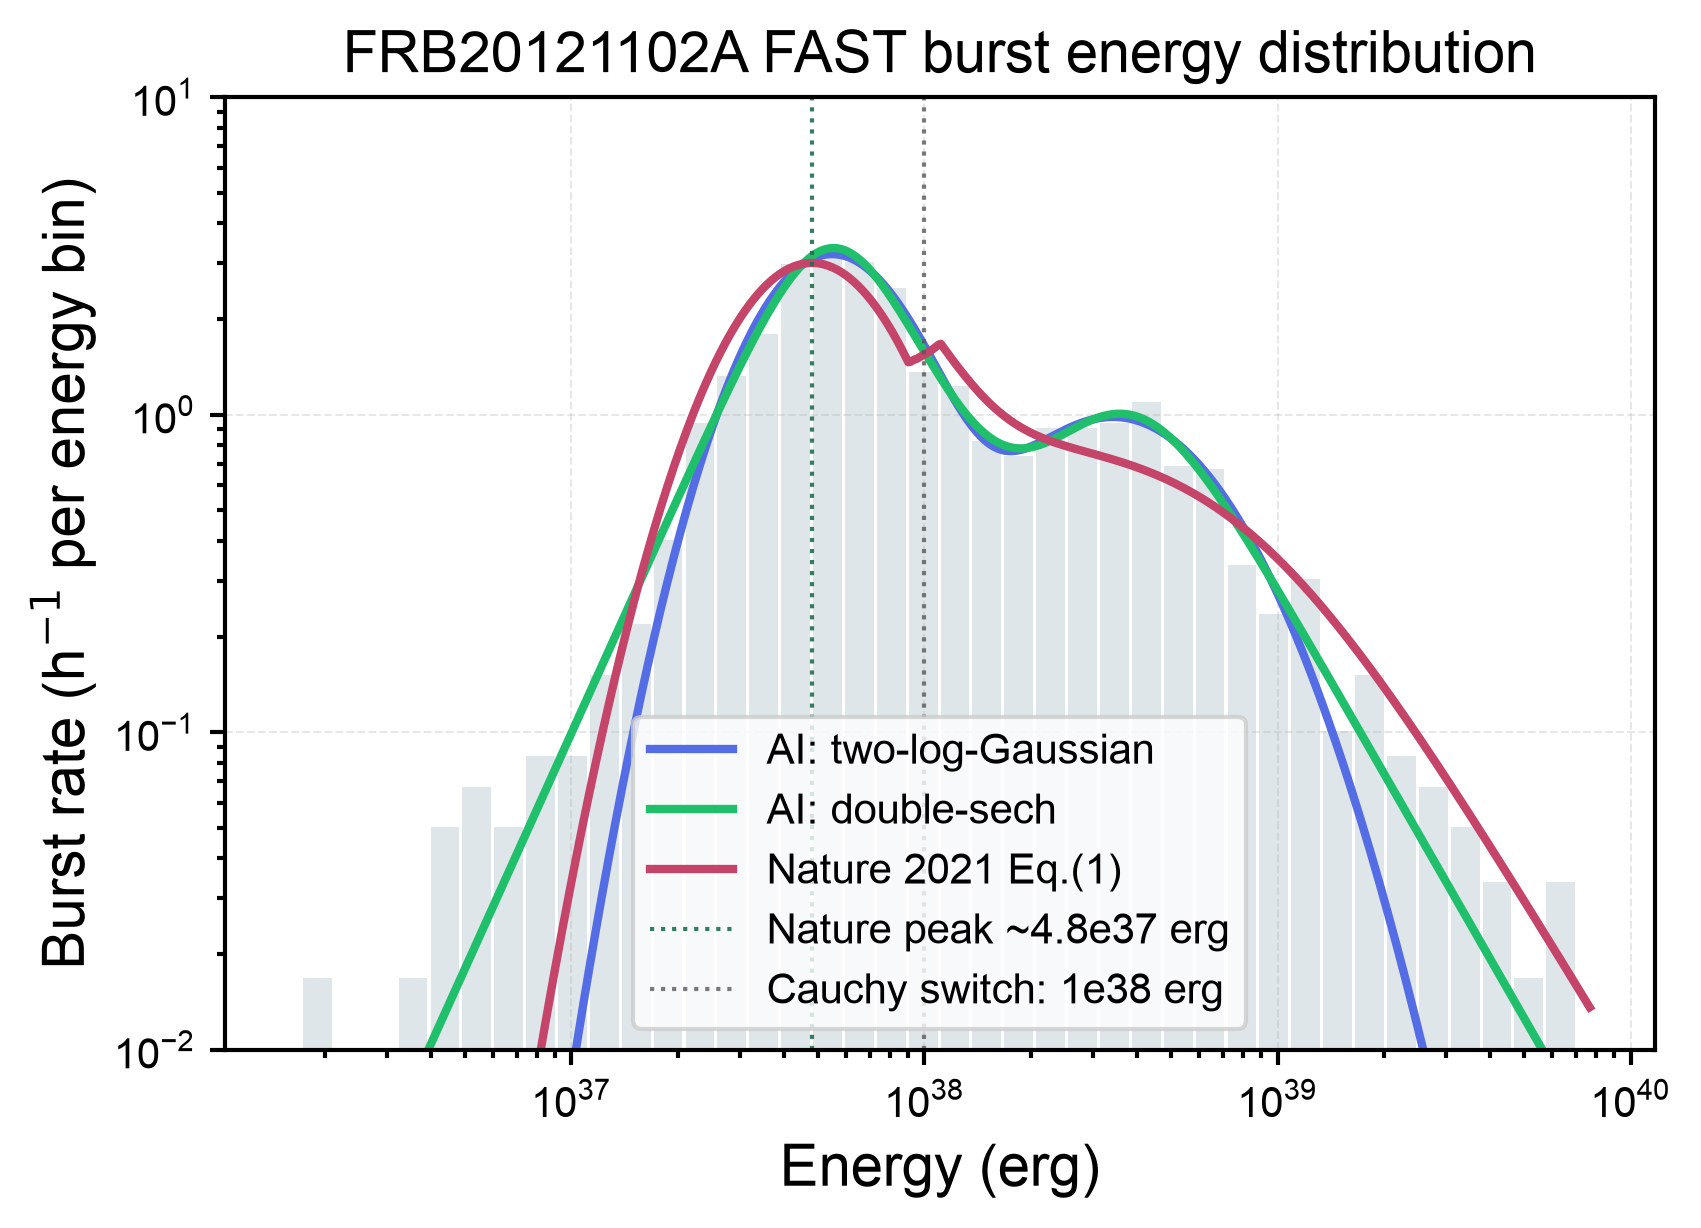

In [31]:
from sr_agent.utils.plot import get_fig

fi, fig, axes = get_fig(1, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)
ax = axes[0]

energy = data['energy_erg']
rate = data['burst_rate_h_per_energy_bin']
bar_width = 0.9 * energy * width_factor

ax.bar(energy, rate, width=bar_width, color='#dfe6e9', align='center')

xx = np.logspace(np.log10(energy.min()) - 0.08, np.log10(energy.max()) + 0.08, 600)
ax.plot(xx, f_ai(xx), color='#546de5', lw=2, label='AI: two-log-Gaussian')
# ax.plot(xx, f_ai2(xx), color='#2d98da', lw=1.5, ls='--', label='AI: two-log-Gaussian loghint')
ax.plot(xx, f_ai3(xx), color='#20bf6b', lw=2, label='AI: double-sech')
ax.plot(xx, f_nature(xx), color='#c44569', lw=2, label='Nature 2021 Eq.(1)')
ax.axvline(4.8e37, color='#1f6f50', lw=1, ls=':', alpha=0.9, label='Nature peak ~4.8e37 erg')
ax.axvline(1e38, color='0.35', lw=1, ls=':', alpha=0.8, label='Cauchy switch: 1e38 erg')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e-2, 1e1)
ax.set_xlabel('Energy (erg)')
ax.set_ylabel('Burst rate (h$^{-1}$ per energy bin)')
ax.set_title('FRB20121102A FAST burst energy distribution')
ax.legend()
ax.grid('on', alpha=0.3, linestyle='--', linewidth=0.5)
fig.tight_layout()
